# Model 3: One attention head

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
# load GPT2 tokenizer
from transformers import GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

## Hyperparameters

In [3]:
seq_len = 8
n_vocab = tokenizer.vocab_size

embed_dim = 2**6 #64

batch_size = 5

## The model

In [4]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        # embedding matrices
        self.embedding = nn.Embedding(n_vocab, embed_dim)
        self.positions = nn.Embedding(seq_len, embed_dim)

        # final output linear layer (unembeddings)
        self.finalLinear = nn.Linear(embed_dim, n_vocab, bias=False)

        # initialize the k,q,v matrices for attention
        self.layernormA = nn.LayerNorm(embed_dim)
        self.key   = nn.Linear(embed_dim, embed_dim, bias=False)
        self.query = nn.Linear(embed_dim, embed_dim, bias=False)
        self.value = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W0    = nn.Linear(embed_dim, embed_dim)

        # the fianl output layer is tied to the token embeddings
        self.finalLinear.weight = nn.Parameter(self.embedding.weight)
    

    def forward(self, tokx):
        # create the token + position embedding
        token_embed = self.embedding(tokx)
        posit_embed = self.positions(torch.arange(tokx.shape[-1])) # [numtokens, embedding_dims]

        # their sum is the output of the embeddings (the addition will broadcast for batch>1)
        x = token_embed + posit_embed # [batch, numtokens, embedding_dims]

        ## --- attention sublayer begins here
        # layernorm before attention
        x = self.layernormA(x)

        # attention algo
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        qk = q @ k.transpose(-2,-1) # dot product between query and keys (would be cosine similiarity if normalized)
        qk_scaled = qk / (embed_dim ** .5) # variance-scale the QK (for this model, embed_dim = head_size)
        pastmask = torch.tril(torch.ones(x.shape[0], seq_len, seq_len)) # apply mask for future tokens
        qk_scaled[pastmask==0] = -torch.inf
        qk_softmax = F.softmax(qk_scaled, dim=-1) # softmaxify
        y = qk_softmax @ v # final attention mechanism

        y *= self.W0(y)
        ## --- end attention

        # -0-
        # MLP sublayer 
        # -0-

        # final output transformation (unembeddings)
        y = self.finalLinear(y) / np.sqrt(embed_dim)

        return y, (pastmask, qk_scaled, qk_softmax) # output some attention matrices for inspection (hooks are better in real models!)


    def generate(self, tokx, temperature=1, n_new_tokens=50):

        # tokx is [batch, tokens]
        for _ in range(n_new_tokens):

            # get predictions, but only from the past seq_len tokens
            x = self(tokx[:,-seq_len:])[0] # [batch, seq_len, n_vocab]

            # extract the final token to predict the next
            x = x[:,-1,:] # [batch, n_vocab]

            # apply softmax to get probability values over all tokens in the vocab - with temperature
            probs = F.softmax(x/temperature,dim=-1) # [batch, n_vocab]

            # probabilistically sample from the distribution
            tokx_next = torch.multinomial(probs,num_samples=1) # [batch, 1]

            # append
            tokx = torch.cat( (tokx,tokx_next),dim=1) # [batch, (tokens+1)]

        return tokx

## Calculate Logits (model output)

In [5]:
# create data
tokens = tokenizer.encode('I prefer oat milk in my coffee.')
X = torch.tensor(tokens[:-1]).unsqueeze(0)
y = torch.tensor(tokens[1:]).unsqueeze(0)

print(X.shape)
print(y.shape)

torch.Size([1, 8])
torch.Size([1, 8])


In [6]:
model = Model()
out, attn = model(X)

print(out.shape)

torch.Size([1, 8, 50257])


In [7]:
print(f'Expected loss for random weights: {-np.log(1/tokenizer.vocab_size):.3f}')
print(f'Observed mean log-softmax output: {torch.mean(-F.log_softmax(out.detach(),dim=-1)):.3f}')
print(f'Cross-entropy loss from pytorch:  {F.cross_entropy(out.view(-1, out.shape[-1]), y.view(-1)):.3f}')

Expected loss for random weights: 10.825
Observed mean log-softmax output: 10.829
Cross-entropy loss from pytorch:  10.854


In [8]:
print('Time-causal mask:\n',attn[0])
print('\nqk_scaled:\n',attn[1])
print('\nqk_softmax:\n',attn[2])

Time-causal mask:
 tensor([[[1., 0., 0., 0., 0., 0., 0., 0.],
         [1., 1., 0., 0., 0., 0., 0., 0.],
         [1., 1., 1., 0., 0., 0., 0., 0.],
         [1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0.],
         [1., 1., 1., 1., 1., 1., 1., 0.],
         [1., 1., 1., 1., 1., 1., 1., 1.]]])

qk_scaled:
 tensor([[[-0.2236,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,
             -inf],
         [ 0.2534,  0.2043,    -inf,    -inf,    -inf,    -inf,    -inf,
             -inf],
         [-0.5657, -0.4296,  1.1548,    -inf,    -inf,    -inf,    -inf,
             -inf],
         [ 0.0061, -0.0394, -0.0950, -0.2893,    -inf,    -inf,    -inf,
             -inf],
         [-0.1643,  0.3270, -0.3111, -0.0978,  0.0267,    -inf,    -inf,
             -inf],
         [ 0.0962,  0.1208, -0.1448,  0.0626,  0.3602, -0.2472,    -inf,
             -inf],
         [ 0.1095,  0.2084, -0.5066,  0.0620,  0.3756,  0.1179, 

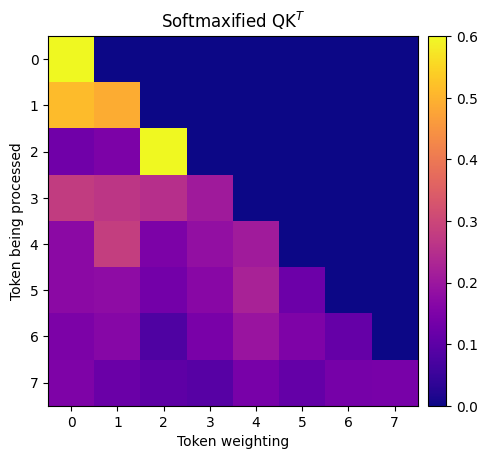

In [9]:
plt.imshow(attn[2].detach().squeeze(), vmin=0, vmax=.6, cmap='plasma')
plt.gca().set(xlabel='Token weighting',
              ylabel='Token being processed',
              title='Softmaxified QK$^T$')
plt.colorbar(pad=.02)
plt.show()

In [10]:
# sanity-check ;)
attn[2].detach().squeeze().sum(dim=1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

## Generate text

In [11]:
# start with some new tokens
text = 'When I grow up, I want to be a'
tokens = tokenizer.encode(text)
tokens = torch.tensor(tokens).unsqueeze(0)

generated_tokens = model.generate(tokens, temperature=2, n_new_tokens=10)[0]

# let's see how it loks!
tokenizer.decode(generated_tokens.tolist())

'When I grow up, I want to be a ReviewsDepthTal CromParameter interoper Janeiro invitation manipulative counter'

In [12]:
# repeat with different temperature values
temps = [.2,.7,1,2,10] # outrageous values ...

for T in temps:
    tokz = model.generate(tokens, temperature=T, n_new_tokens=10)
    tokz = tokz[0].tolist()
    print(f'Temp = {T}:\n  {tokenizer.decode(tokz)}\n')

Temp = 0.2:
  When I grow up, I want to be a starts MON judgesstartedgas Shak Pirate theorists Chev dispersed

Temp = 0.7:
  When I grow up, I want to be a debtor Rome Tillerson fan Carnegie puppies Control OC></ amaz

Temp = 1:
  When I grow up, I want to be a flatsDavis pinespecies cer Moj mate++++++++++++++++ Astro pots

Temp = 2:
  When I grow up, I want to be a fashioned confidentialabiding Luxembourg lex ECB randomizedlib scalingGo

Temp = 10:
  When I grow up, I want to be a patents crucialtp permission Broken scoreboardcil agile No copper

